In [1]:
import pickle
import itertools
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Carga de Datos

In [3]:
class CloudscapeDataset:
    def __init__(self, df_architectures=None, df_nodes=None, df_edges=None, graphs=None):
        self.architectures = df_architectures
        self.nodes = df_nodes
        self.edges = df_edges
        self.graphs = graphs

In [4]:
BASE_DIR = Path(".")
BUNDLE_PATH = BASE_DIR / "output_analytics" / "cloudscape_pipeline_bundle.pkl"

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

df_services_master: pl.DataFrame = bundle["df_services_master"]
G_cooc_master: nx.Graph = bundle["G_cooc_master"]
df_cooccurrences: pl.DataFrame | None = bundle.get("df_cooccurrences")

print(f"Servicios: {G_cooc_master.number_of_nodes()}")
print(f"Aristas: {G_cooc_master.number_of_edges()}")

Servicios: 78
Aristas: 491


# Centralidad y Clasificación

In [5]:
pagerank = nx.pagerank(G_cooc_master, weight='weight')
degree_centrality = nx.degree_centrality(G_cooc_master)
betweenness = nx.betweenness_centrality(G_cooc_master, weight='weight')
closeness = nx.closeness_centrality(G_cooc_master, distance='weight')

try:
    eigenvector = nx.eigenvector_centrality(G_cooc_master, weight='weight', max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = nx.eigenvector_centrality_numpy(G_cooc_master, weight='weight')

centralidad_data = []
for service in G_cooc_master.nodes():
    row = df_services_master.filter(pl.col('service') == service)
    num_archs = row['num_architectures'].first() if row.height > 0 else 0
    centralidad_data.append({
        'service': service,
        'num_architectures': num_archs,
        'degree': G_cooc_master.degree(service),
        'pagerank': pagerank.get(service, 0),
        'degree_centrality': degree_centrality.get(service, 0),
        'betweenness': betweenness.get(service, 0),
        'closeness': closeness.get(service, 0),
        'eigenvector': eigenvector.get(service, 0),
    })

df_centralidad = pl.DataFrame(centralidad_data)

for col in ['pagerank', 'degree_centrality', 'betweenness', 'closeness', 'eigenvector']:
    max_val = df_centralidad[col].max()
    if max_val and max_val > 0:
        df_centralidad = df_centralidad.with_columns((pl.col(col) / max_val).alias(col))

df_centralidad = df_centralidad.with_columns(
    (0.30 * pl.col('pagerank') +
     0.25 * pl.col('degree_centrality') +
     0.20 * pl.col('betweenness') +
     0.15 * pl.col('eigenvector') +
     0.10 * pl.col('closeness')).alias('centralidad_score')
)

df_centralidad = df_centralidad.with_columns(
    pl.when(pl.col('centralidad_score') > 0.5).then(pl.lit('Fundamental'))
    .when(pl.col('centralidad_score') > 0.3).then(pl.lit('Integrador'))
    .otherwise(pl.lit('Especializado')).alias('nivel')
).sort('centralidad_score', descending=True)

fundamentales = df_centralidad.filter(pl.col('nivel') == 'Fundamental')['service'].to_list()

print(f"Fundamentales: {len(fundamentales)}")
for s in fundamentales:
    score = df_centralidad.filter(pl.col('service') == s)['centralidad_score'][0]
    print(f"  {s}: {score:.3f}")

if len(fundamentales) < 2:
    raise ValueError("Se necesitan al menos 2 Fundamentales.")

Fundamentales: 4
  S3: 1.000
  Lambda: 0.837
  EC2: 0.598
  DynamoDB: 0.585


# Pares Fundamentales

In [6]:
_COL_A = _COL_B = _COL_W = None

if df_cooccurrences is not None:
    cols = df_cooccurrences.columns
    print(f"Columnas: {cols}")

    candidatos_a = [c for c in cols if c.lower() in
                    ('service_a', 'service_1', 'source', 'service_x', 'servicio_a', 'from')]
    candidatos_b = [c for c in cols if c.lower() in
                    ('service_b', 'service_2', 'target', 'service_y', 'servicio_b', 'to')]
    candidatos_w = [c for c in cols if any(
        kw in c.lower() for kw in ('weight', 'count', 'freq', 'n_coocur', 'coocurren', 'peso', 'veces')
    )]

    if candidatos_a and candidatos_b and candidatos_w:
        _COL_A, _COL_B, _COL_W = candidatos_a[0], candidatos_b[0], candidatos_w[0]
        print(f"Usando: {_COL_A}, {_COL_B}, {_COL_W}")
    else:
        print("No se pudo mapear columnas, usando peso del grafo.")


def obtener_peso_coocurrencia(s1: str, s2: str) -> int:
    if _COL_A is not None:
        fila = df_cooccurrences.filter(
            ((pl.col(_COL_A) == s1) & (pl.col(_COL_B) == s2)) |
            ((pl.col(_COL_A) == s2) & (pl.col(_COL_B) == s1))
        )
        if fila.height > 0:
            return int(fila[_COL_W][0])
    if G_cooc_master.has_edge(s1, s2):
        return int(G_cooc_master[s1][s2].get('weight', 1))
    return 0


archs = {
    s: (df_centralidad.filter(pl.col('service') == s)['num_architectures'][0] or 1)
    for s in fundamentales
}

pares_data = []
for s1, s2 in combinations(fundamentales, 2):
    peso = obtener_peso_coocurrencia(s1, s2)
    compatible = G_cooc_master.has_edge(s1, s2)

    p_b_dado_a = peso / archs[s1] if archs[s1] > 0 else 0.0
    p_a_dado_b = peso / archs[s2] if archs[s2] > 0 else 0.0
    overlap = peso / min(archs[s1], archs[s2]) if min(archs[s1], archs[s2]) > 0 else 0.0

    pares_data.append({
        'servicio_a': s1,
        'servicio_b': s2,
        'compatible': compatible,
        'peso_coocurrencia': peso,
        'prob_b_dado_a': round(p_b_dado_a, 3),
        'prob_a_dado_b': round(p_a_dado_b, 3),
        'overlap_coefficient': round(overlap, 3),
    })

df_pares_fund = pl.DataFrame(pares_data).sort('overlap_coefficient', descending=True)

print("Pares Fundamentales")
print(df_pares_fund)

Columnas: ['service_a', 'service_b', 'cooc_frequency', 'jaccard_similarity']
Usando: service_a, service_b, cooc_frequency
Pares Fundamentales
shape: (6, 7)
┌────────────┬────────────┬────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ servicio_a ┆ servicio_b ┆ compatible ┆ peso_coocurr ┆ prob_b_dado_ ┆ prob_a_dado_ ┆ overlap_coef │
│ ---        ┆ ---        ┆ ---        ┆ encia        ┆ a            ┆ b            ┆ ficient      │
│ str        ┆ str        ┆ bool       ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│            ┆            ┆            ┆ i64          ┆ f64          ┆ f64          ┆ f64          │
╞════════════╪════════════╪════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ Lambda     ┆ DynamoDB   ┆ true       ┆ 92           ┆ 0.449        ┆ 0.807        ┆ 0.807        │
│ S3         ┆ Lambda     ┆ true       ┆ 144          ┆ 0.623        ┆ 0.702        ┆ 0.702        │
│ S3         ┆ DynamoDB   ┆ true    

# Score de Cohesión

In [7]:
n_pares = df_pares_fund.height
n_compatibles = df_pares_fund.filter(pl.col('compatible')).height
pct_compatibles = n_compatibles / n_pares * 100

overlap_promedio_todos = df_pares_fund['overlap_coefficient'].mean()
overlap_promedio_compatibles = (
    df_pares_fund.filter(pl.col('compatible'))['overlap_coefficient'].mean()
    if n_compatibles > 0 else 0.0
)

print("Cohesión Global")
print(f"  Pares: {n_pares}")
print(f"  Compatibles: {n_compatibles} ({pct_compatibles:.1f}%)")
print(f"  Overlap promedio: {overlap_promedio_todos:.3f}")
print(f"  Overlap compatibles: {overlap_promedio_compatibles:.3f}")

cohesion_por_servicio = []
for s in fundamentales:
    sub = df_pares_fund.filter((pl.col('servicio_a') == s) | (pl.col('servicio_b') == s))
    cohesion_por_servicio.append({
        'service': s,
        'overlap_promedio_con_grupo': round(sub['overlap_coefficient'].mean(), 3),
        'pares_incompatibles': sub.filter(~pl.col('compatible')).height,
    })

df_cohesion_servicio = pl.DataFrame(cohesion_por_servicio).sort(
    'overlap_promedio_con_grupo', descending=True
)

print("Cohesión Individual")
print(df_cohesion_servicio)

Cohesión Global
  Pares: 6
  Compatibles: 6 (100.0%)
  Overlap promedio: 0.599
  Overlap compatibles: 0.599
Cohesión Individual
shape: (4, 3)
┌──────────┬────────────────────────────┬─────────────────────┐
│ service  ┆ overlap_promedio_con_grupo ┆ pares_incompatibles │
│ ---      ┆ ---                        ┆ ---                 │
│ str      ┆ f64                        ┆ i64                 │
╞══════════╪════════════════════════════╪═════════════════════╡
│ S3       ┆ 0.675                      ┆ 0                   │
│ Lambda   ┆ 0.663                      ┆ 0                   │
│ DynamoDB ┆ 0.585                      ┆ 0                   │
│ EC2      ┆ 0.473                      ┆ 0                   │
└──────────┴────────────────────────────┴─────────────────────┘


# Heatmap

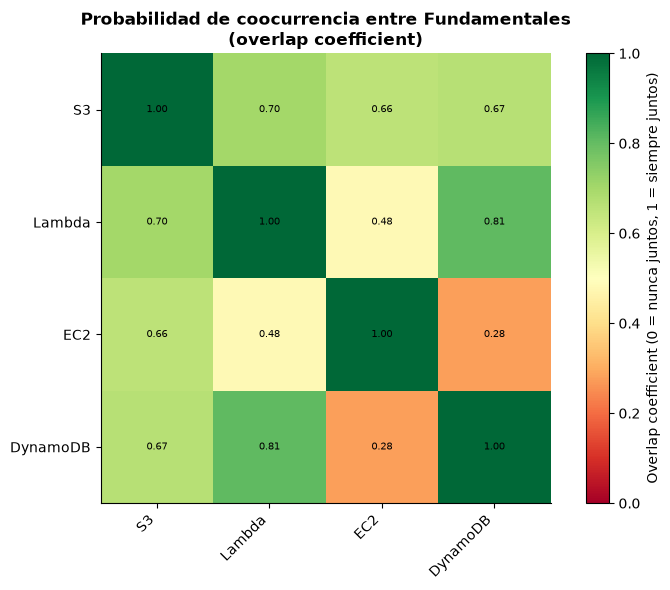

In [8]:
n = len(fundamentales)
matriz_overlap = np.zeros((n, n))

for i, s1 in enumerate(fundamentales):
    for j, s2 in enumerate(fundamentales):
        if i == j:
            matriz_overlap[i, j] = 1.0
            continue
        fila = df_pares_fund.filter(
            ((pl.col('servicio_a') == s1) & (pl.col('servicio_b') == s2)) |
            ((pl.col('servicio_a') == s2) & (pl.col('servicio_b') == s1))
        )
        matriz_overlap[i, j] = fila['overlap_coefficient'][0] if fila.height > 0 else 0.0

fig, ax = plt.subplots(figsize=(max(8, n * 0.7), max(6, n * 0.7)))
im = ax.imshow(matriz_overlap, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(fundamentales, rotation=45, ha='right')
ax.set_yticklabels(fundamentales)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{matriz_overlap[i, j]:.2f}", ha='center', va='center',
                fontsize=7, color='black')

ax.set_title('Probabilidad de coocurrencia entre Fundamentales\n(overlap coefficient)',
              fontweight='bold')
fig.colorbar(im, ax=ax, label='Overlap coefficient (0 = nunca juntos, 1 = siempre juntos)')
plt.tight_layout()
plt.savefig('heatmap_cohesion_fundamentales.png', dpi=300, bbox_inches='tight')
plt.show()

# Exportar Resultados

In [9]:
df_centralidad.write_csv('centralidad_servicios.csv')
df_pares_fund.write_csv('pares_fundamentales_coocurrencia.csv')
df_cohesion_servicio.write_csv('cohesion_fundamentales_por_servicio.csv')

print("Exportado:")
print("  - centralidad_servicios.csv")
print("  - pares_fundamentales_coocurrencia.csv")
print("  - cohesion_fundamentales_por_servicio.csv")
print("  - heatmap_cohesion_fundamentales.png")

Exportado:
  - centralidad_servicios.csv
  - pares_fundamentales_coocurrencia.csv
  - cohesion_fundamentales_por_servicio.csv
  - heatmap_cohesion_fundamentales.png


# Sustitutos Fundamentales

In [10]:
UMBRAL_SUSTITUTO = 0.50

DATA_DIR = BASE_DIR / "data"
SERVICES_CSV = DATA_DIR / "services.csv"

df_services_cat = pl.read_csv(SERVICES_CSV).select(['name', 'aws_product_categories'])
cat_map_raw = {}
for row in df_services_cat.iter_rows(named=True):
    cats = [c.strip() for c in row['aws_product_categories'].split(',')] if row['aws_product_categories'] else []
    cat_map_raw[row['name']] = cats

group_mapping = {
    'Compute': ['Compute'],
    'Storage': ['Storage'],
    'Networking': ['Networking and Content Delivery'],
    'Integration': ['Application Integration'],
    'Analytics': ['Analytics'],
    'Security': ['Security Identity and Compliance'],
    'Management': ['Management and Governance'],
    'IoT': ['IoT'],
    'Media': ['Media Services'],
    'Developer': ['Developer Tools'],
    'Database': ['Database'],
    'ML': ['ML'],
    'Other': [],
}


def get_service_category(service: str) -> str:
    cats = cat_map_raw.get(service, [])
    for group, keywords in group_mapping.items():
        for kw in keywords:
            if any(kw in c for c in cats):
                return group
    cap = df_services_master.filter(pl.col('service') == service)['capability'].first()
    return {'compute': 'Compute', 'storage': 'Storage', 'networking': 'Networking',
            'integration': 'Integration'}.get(cap, 'Other')


categoria_map = {s: get_service_category(s) for s in fundamentales}

pares_sustitutos = (
    df_pares_fund
    .filter(pl.col('overlap_coefficient') < UMBRAL_SUSTITUTO)
    .with_columns([
        pl.col('servicio_a').replace_strict(categoria_map).alias('categoria_a'),
        pl.col('servicio_b').replace_strict(categoria_map).alias('categoria_b'),
    ])
    .with_columns((pl.col('categoria_a') == pl.col('categoria_b')).alias('misma_categoria'))
    .sort(['misma_categoria', 'overlap_coefficient'], descending=[True, False])
)

print(f"Pares con overlap < {UMBRAL_SUSTITUTO:.0%}:")
print(pares_sustitutos.select(['servicio_a', 'servicio_b', 'overlap_coefficient', 'misma_categoria']))

Pares con overlap < 50%:
shape: (2, 4)
┌────────────┬────────────┬─────────────────────┬─────────────────┐
│ servicio_a ┆ servicio_b ┆ overlap_coefficient ┆ misma_categoria │
│ ---        ┆ ---        ┆ ---                 ┆ ---             │
│ str        ┆ str        ┆ f64                 ┆ bool            │
╞════════════╪════════════╪═════════════════════╪═════════════════╡
│ Lambda     ┆ EC2        ┆ 0.481               ┆ true            │
│ EC2        ┆ DynamoDB   ┆ 0.281               ┆ false           │
└────────────┴────────────┴─────────────────────┴─────────────────┘


In [11]:
overlap_lookup: dict[tuple[str, str], float] = {}
for row in df_pares_fund.iter_rows(named=True):
    overlap_lookup[(row['servicio_a'], row['servicio_b'])] = row['overlap_coefficient']
    overlap_lookup[(row['servicio_b'], row['servicio_a'])] = row['overlap_coefficient']

parent = {s: s for s in fundamentales}
miembros_por_raiz: dict[str, list[str]] = {s: [s] for s in fundamentales}


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def intentar_union(a: str, b: str) -> bool:
    ra, rb = find(a), find(b)
    if ra == rb:
        return True

    miembros_a = miembros_por_raiz[ra]
    miembros_b = miembros_por_raiz[rb]

    for m in miembros_a:
        for n in miembros_b:
            ov = overlap_lookup.get((m, n))
            if ov is not None and ov >= UMBRAL_SUSTITUTO:
                print(f"  BLOQUEADO {a}+{b}: {m} vs {n} overlap {ov:.3f}")
                return False

    parent[ra] = rb
    miembros_por_raiz[rb] = miembros_a + miembros_b
    del miembros_por_raiz[ra]
    return True


print("Procesando fusiones:")
for row in pares_sustitutos.iter_rows(named=True):
    s1, s2 = row['servicio_a'], row['servicio_b']
    fusionado = intentar_union(s1, s2)
    if fusionado:
        print(f"  OK: {s1} + {s2} (overlap {row['overlap_coefficient']:.3f})")

grupos_sustitutos: dict[str, list[str]] = {}
for s in fundamentales:
    raiz = find(s)
    grupos_sustitutos.setdefault(raiz, []).append(s)

Procesando fusiones:
  OK: Lambda + EC2 (overlap 0.481)
  BLOQUEADO EC2+DynamoDB: Lambda vs DynamoDB overlap 0.807


# Pares Integrador-Fundamental

In [12]:
integradores = df_centralidad.filter(pl.col('nivel') == 'Integrador')['service'].to_list()

archs_integradores = {
    s: (df_centralidad.filter(pl.col('service') == s)['num_architectures'][0] or 1)
    for s in integradores
}

pares_integrador_fundamental = []
for integ in integradores:
    for fund in fundamentales:
        peso = obtener_peso_coocurrencia(integ, fund)
        base = min(archs_integradores[integ], archs[fund])
        overlap = peso / base if base > 0 else 0.0
        pares_integrador_fundamental.append({
            'integrador': integ,
            'fundamental': fund,
            'peso_coocurrencia': peso,
            'overlap_coefficient': round(overlap, 3),
            'compatible': G_cooc_master.has_edge(integ, fund),
        })

df_pares_integ_fund = pl.DataFrame(pares_integrador_fundamental)

df_bajos_integ_fund = (
    df_pares_integ_fund
    .filter(pl.col('overlap_coefficient') < UMBRAL_SUSTITUTO)
    .sort('overlap_coefficient')
)

print(f"Overlap < {UMBRAL_SUSTITUTO:.0%}:")
print(df_bajos_integ_fund)

Overlap < 50%:
shape: (13, 5)
┌───────────────┬─────────────┬───────────────────┬─────────────────────┬────────────┐
│ integrador    ┆ fundamental ┆ peso_coocurrencia ┆ overlap_coefficient ┆ compatible │
│ ---           ┆ ---         ┆ ---               ┆ ---                 ┆ ---        │
│ str           ┆ str         ┆ i64               ┆ f64                 ┆ bool       │
╞═══════════════╪═════════════╪═══════════════════╪═════════════════════╪════════════╡
│ StepFunctions ┆ EC2         ┆ 5                 ┆ 0.114               ┆ true       │
│ RDS           ┆ DynamoDB    ┆ 15                ┆ 0.217               ┆ true       │
│ EKS           ┆ DynamoDB    ┆ 13                ┆ 0.232               ┆ true       │
│ EKS           ┆ Lambda      ┆ 14                ┆ 0.25                ┆ true       │
│ ApiGateway    ┆ EC2         ┆ 25                ┆ 0.275               ┆ true       │
│ …             ┆ …           ┆ …                 ┆ …                   ┆ …          │
│ StepFunctio

# Asignar Integradores

In [13]:
def son_incompatibles(s1: str, s2: str, G: nx.Graph) -> bool:
    if s1 == s2:
        return False
    if not G.has_node(s1) or not G.has_node(s2):
        return True
    return not G.has_edge(s1, s2)


def buscar_conflicto_con_otros_dados(servicio: str, dado_excluir: str, dados_actuales: dict, G: nx.Graph):
    for dado_id, info in dados_actuales.items():
        if dado_id == dado_excluir:
            continue
        for miembro in info['miembros']:
            if son_incompatibles(servicio, miembro, G):
                return (dado_id, miembro)
    return None


dados: dict[str, dict] = {}
for i, (_, miembros) in enumerate(grupos_sustitutos.items(), 1):
    dado_id = f"Dado_{i}"
    dados[dado_id] = {'miembros': list(miembros)}

fundamental_a_dado = {
    s: dado_id
    for dado_id, info in dados.items()
    for s in info['miembros']
}

integrador_min_overlap: dict[str, dict] = {}
for row in df_bajos_integ_fund.iter_rows(named=True):
    integ = row['integrador']
    if integ not in integrador_min_overlap or row['overlap_coefficient'] < integrador_min_overlap[integ]['overlap_coefficient']:
        integrador_min_overlap[integ] = row

no_asignados_integradores = []

print("Evaluando Integradores:")
for integ, row in integrador_min_overlap.items():
    fund_afin = row['fundamental']
    overlap = row['overlap_coefficient']

    cat_integ = get_service_category(integ)
    cat_fund = get_service_category(fund_afin)

    if cat_integ != cat_fund:
        no_asignados_integradores.append(integ)
        print(f"  NO ASIGNADO: {integ} ({cat_integ}) vs {fund_afin} ({cat_fund}), tipos distintos")
        continue

    dado_id = fundamental_a_dado[fund_afin]

    conflicto = buscar_conflicto_con_otros_dados(integ, dado_id, dados, G_cooc_master)
    if conflicto:
        dado_conflicto, miembro_conflicto = conflicto
        no_asignados_integradores.append(integ)
        print(f"  NO ASIGNADO: {integ}, conflicto con {miembro_conflicto} ({dado_conflicto})")
        continue

    dados[dado_id]['miembros'].append(integ)
    print(f"  OK: {integ} ({cat_integ}) -> {dado_id} (via {fund_afin}, overlap {overlap:.3f})")

print(f"Sin asignar: {no_asignados_integradores}")

print("Dados tras asignar Integradores")
for dado_id, info in dados.items():
    tipos = [get_service_category(m) for m in info['miembros']]
    print(f"  {dado_id}: {info['miembros']} ({tipos})")

Evaluando Integradores:
  NO ASIGNADO: StepFunctions (Integration) vs EC2 (Compute), tipos distintos
  OK: RDS (Database) -> Dado_3 (via DynamoDB, overlap 0.217)
  NO ASIGNADO: EKS (Compute) vs DynamoDB (Database), tipos distintos
  NO ASIGNADO: ApiGateway (Networking) vs EC2 (Compute), tipos distintos
  NO ASIGNADO: SQS (Integration) vs DynamoDB (Database), tipos distintos
  NO ASIGNADO: OpenSearch (Analytics) vs EC2 (Compute), tipos distintos
Sin asignar: ['StepFunctions', 'EKS', 'ApiGateway', 'SQS', 'OpenSearch']
Dados tras asignar Integradores
  Dado_1: ['S3'] (['Storage'])
  Dado_2: ['Lambda', 'EC2'] (['Compute', 'Compute'])
  Dado_3: ['DynamoDB', 'RDS'] (['Database', 'Database'])


# Reporte de Conflictos

In [14]:
LIMITE_EXHAUSTIVO = 200_000


def son_incompatibles(s1: str, s2: str, G: nx.Graph) -> bool:
    if s1 == s2:
        return False
    if not G.has_node(s1) or not G.has_node(s2):
        return True
    return not G.has_edge(s1, s2)


def reporte_dados(dados: dict, G: nx.Graph, top_n: int = 15) -> pl.DataFrame:
    listas = [info['miembros'] for info in dados.values()]
    total = 1
    for lst in listas:
        total *= len(lst)

    if total <= LIMITE_EXHAUSTIVO:
        generador, n_evaluadas, modo = itertools.product(*listas), total, "exhaustivo"
    else:
        generador = (tuple(np.random.choice(lst) for lst in listas) for _ in range(LIMITE_EXHAUSTIVO))
        n_evaluadas, modo = LIMITE_EXHAUSTIVO, "simulación"

    stats = defaultdict(lambda: {'incompatible_con': Counter(), 'n_conflictos': 0})
    combos_con_conflicto = 0

    for combo in generador:
        conflicto = False
        for s1, s2 in combinations(combo, 2):
            if son_incompatibles(s1, s2, G):
                conflicto = True
                stats[s1]['incompatible_con'][s2] += 1
                stats[s1]['n_conflictos'] += 1
                stats[s2]['incompatible_con'][s1] += 1
                stats[s2]['n_conflictos'] += 1
        combos_con_conflicto += conflicto

    pct = combos_con_conflicto / n_evaluadas * 100
    print(f"[{modo}] {n_evaluadas} combinaciones | conflicto: {combos_con_conflicto} ({pct:.1f}%)")

    if not stats:
        print("Sin conflictos.")
        return pl.DataFrame()

    servicio_a_dado = {s: d for d, info in dados.items() for s in info['miembros']}

    filas = []
    for serv, info in stats.items():
        pop_row = df_centralidad.filter(pl.col('service') == serv)['num_architectures']
        incompatibles = sorted(info['incompatible_con'].items(), key=lambda x: -x[1])
        filas.append({
            'service': serv,
            'dado': servicio_a_dado.get(serv),
            'tipo': get_service_category(serv),
            'popularidad': pop_row[0] if len(pop_row) > 0 else 0,
            'n_conflictos': info['n_conflictos'],
            'incompatible_con': ', '.join(f"{s}({c})" for s, c in incompatibles),
        })

    df_reporte = pl.DataFrame(filas).sort('n_conflictos', descending=True)
    print(df_reporte.head(top_n))
    return df_reporte


print("Reporte Sección 9")
df_reporte_9 = reporte_dados(dados, G_cooc_master)

Reporte Sección 9
[exhaustivo] 4 combinaciones | conflicto: 0 (0.0%)
Sin conflictos.


# Sustitutos Integradores

In [15]:
integradores_pendientes = no_asignados_integradores.copy()
print(f"Pendientes: {integradores_pendientes}")

if len(integradores_pendientes) < 2:
    print("No hay suficientes pendientes para evaluar pares.")
    pares_sustitutos_integ = pl.DataFrame(
        schema={'integrador_a': pl.String, 'integrador_b': pl.String,
                'overlap_coefficient': pl.Float64, 'misma_categoria': pl.Boolean}
    )
else:
    pares_integ_data = []
    for i1, i2 in combinations(integradores_pendientes, 2):
        peso = obtener_peso_coocurrencia(i1, i2)
        base = min(archs_integradores[i1], archs_integradores[i2])
        overlap = peso / base if base > 0 else 0.0
        pares_integ_data.append({
            'integrador_a': i1,
            'integrador_b': i2,
            'peso_coocurrencia': peso,
            'overlap_coefficient': round(overlap, 3),
            'compatible': G_cooc_master.has_edge(i1, i2),
        })

    df_pares_integ = pl.DataFrame(pares_integ_data)
    categoria_map_integ = {s: get_service_category(s) for s in integradores_pendientes}

    pares_sustitutos_integ = (
        df_pares_integ
        .filter((pl.col('overlap_coefficient') < UMBRAL_SUSTITUTO))
        .with_columns([
            pl.col('integrador_a').replace_strict(categoria_map_integ).alias('categoria_a'),
            pl.col('integrador_b').replace_strict(categoria_map_integ).alias('categoria_b'),
        ])
        .filter(pl.col('categoria_a') == pl.col('categoria_b'))
        .sort('overlap_coefficient')
    )

    print(f"Pares con overlap < {UMBRAL_SUSTITUTO:.0%} y misma categoría:")
    print(pares_sustitutos_integ.select(['integrador_a', 'integrador_b', 'overlap_coefficient']))

    overlap_lookup_integ: dict[tuple[str, str], float] = {}
    for row in df_pares_integ.iter_rows(named=True):
        overlap_lookup_integ[(row['integrador_a'], row['integrador_b'])] = row['overlap_coefficient']
        overlap_lookup_integ[(row['integrador_b'], row['integrador_a'])] = row['overlap_coefficient']

    parent_integ = {s: s for s in integradores_pendientes}
    miembros_por_raiz_integ: dict[str, list[str]] = {s: [s] for s in integradores_pendientes}


    def find_integ(x):
        while parent_integ[x] != x:
            parent_integ[x] = parent_integ[parent_integ[x]]
            x = parent_integ[x]
        return x


    def intentar_union_integ(a: str, b: str) -> bool:
        ra, rb = find_integ(a), find_integ(b)
        if ra == rb:
            return True

        miembros_a = miembros_por_raiz_integ[ra]
        miembros_b = miembros_por_raiz_integ[rb]

        for m in miembros_a:
            for n in miembros_b:
                ov = overlap_lookup_integ.get((m, n))
                if ov is not None and ov >= UMBRAL_SUSTITUTO:
                    print(f"  BLOQUEADO {a}+{b}: {m} vs {n} overlap {ov:.3f}")
                    return False

        parent_integ[ra] = rb
        miembros_por_raiz_integ[rb] = miembros_a + miembros_b
        del miembros_por_raiz_integ[ra]
        return True


    print("Procesando fusiones:")
    for row in pares_sustitutos_integ.iter_rows(named=True):
        a, b = row['integrador_a'], row['integrador_b']
        if intentar_union_integ(a, b):
            print(f"  OK: {a} + {b} (overlap {row['overlap_coefficient']:.3f})")

    grupos_sustitutos_integ: dict[str, list[str]] = {}
    for s in integradores_pendientes:
        raiz = find_integ(s)
        grupos_sustitutos_integ.setdefault(raiz, []).append(s)

    grupos_ordenados = sorted(
        grupos_sustitutos_integ.values(),
        key=lambda miembros: sum(archs_integradores.get(m, 0) for m in miembros),
        reverse=True
    )

    siguiente_num = len(dados) + 1
    descartados_integradores_finales = []

    for miembros in grupos_ordenados:
        dado_id = f"Dado_{siguiente_num}"
        siguiente_num += 1

        grupo_valido = []
        for miembro in miembros:
            conflicto = buscar_conflicto_con_otros_dados(miembro, dado_id, dados, G_cooc_master)
            if conflicto:
                dado_conf, miembro_conf = conflicto
                print(f"  DESCARTADO {miembro}: incompatible con {miembro_conf} ({dado_conf})")
                descartados_integradores_finales.append(miembro)
            else:
                grupo_valido.append(miembro)

        if grupo_valido:
            dados[dado_id] = {'miembros': grupo_valido}
            etiqueta = f"grupo de {len(grupo_valido)}" if len(grupo_valido) > 1 else "solo"
            print(f"  {dado_id} [{etiqueta}]: {grupo_valido}")

    if descartados_integradores_finales:
        print(f"Descartados por conflicto: {descartados_integradores_finales}")

print("Dados tras agrupar sobrantes")
for dado_id, info in dados.items():
    tipos = [get_service_category(m) for m in info['miembros']]
    print(f"  {dado_id}: {info['miembros']} ({tipos})")

print("Reporte Sección 11")
df_reporte_11 = reporte_dados(dados, G_cooc_master)

Pendientes: ['StepFunctions', 'EKS', 'ApiGateway', 'SQS', 'OpenSearch']
Pares con overlap < 50% y misma categoría:
shape: (1, 3)
┌───────────────┬──────────────┬─────────────────────┐
│ integrador_a  ┆ integrador_b ┆ overlap_coefficient │
│ ---           ┆ ---          ┆ ---                 │
│ str           ┆ str          ┆ f64                 │
╞═══════════════╪══════════════╪═════════════════════╡
│ StepFunctions ┆ SQS          ┆ 0.159               │
└───────────────┴──────────────┴─────────────────────┘
Procesando fusiones:
  OK: StepFunctions + SQS (overlap 0.159)
  Dado_4 [grupo de 2]: ['StepFunctions', 'SQS']
  Dado_5 [solo]: ['ApiGateway']
  DESCARTADO EKS: incompatible con StepFunctions (Dado_4)
  DESCARTADO OpenSearch: incompatible con SQS (Dado_4)
Descartados por conflicto: ['EKS', 'OpenSearch']
Dados tras agrupar sobrantes
  Dado_1: ['S3'] (['Storage'])
  Dado_2: ['Lambda', 'EC2'] (['Compute', 'Compute'])
  Dado_3: ['DynamoDB', 'RDS'] (['Database', 'Database'])
  Dado_4: [

# Encajar Especializados

In [16]:
MAX_CARAS_POR_DADO = 6

ya_asignados = {s for info in dados.values() for s in info['miembros']}

especializados_df = df_centralidad.filter(
    (pl.col('nivel') == 'Especializado') & (~pl.col('service').is_in(ya_asignados))
).sort('num_architectures', descending=True)
especializados = especializados_df['service'].to_list()

print(f"A evaluar: {len(especializados)} ({len(ya_asignados)} ya asignados)")


def tipo_homogeneo_del_dado(info: dict):
    tipos = {get_service_category(m) for m in info['miembros']}
    return tipos.pop() if len(tipos) == 1 else None


descartados_especializados = []
colocados_especializados = []

for serv in especializados:
    tipo_serv = get_service_category(serv)

    candidatos = [
        (dado_id, info) for dado_id, info in dados.items()
        if tipo_homogeneo_del_dado(info) == tipo_serv and len(info['miembros']) < MAX_CARAS_POR_DADO
    ]
    candidatos.sort(key=lambda kv: len(kv[1]['miembros']))

    colocado = False
    for dado_id, info in candidatos:
        conflicto = buscar_conflicto_con_otros_dados(serv, dado_id, dados, G_cooc_master)
        if conflicto is None:
            info['miembros'].append(serv)
            print(f"  {serv} ({tipo_serv}) -> {dado_id}")
            colocados_especializados.append((serv, dado_id))
            colocado = True
            break
        else:
            dado_conf, miembro_conf = conflicto
            print(f"    {serv} choca con {miembro_conf} ({dado_conf}), probando otro dado...")

    if not colocado:
        print(f"  {serv} ({tipo_serv}) -> no encajó, pasa a 2da pasada")
        descartados_especializados.append(serv)

print(f"1ra pasada: colocados {len(colocados_especializados)} | pendientes {len(descartados_especializados)}")

descartados_definitivos = []

if descartados_especializados:
    print("2da pasada: agrupando pendientes por tipo")

    por_tipo: dict[str, list[str]] = {}
    for serv in descartados_especializados:
        por_tipo.setdefault(get_service_category(serv), []).append(serv)

    siguiente_num = len(dados) + 1
    for tipo, servicios in por_tipo.items():
        for inicio in range(0, len(servicios), MAX_CARAS_POR_DADO):
            candidatos_grupo = servicios[inicio:inicio + MAX_CARAS_POR_DADO]
            dado_id = f"Dado_{siguiente_num}"
            siguiente_num += 1

            grupo_valido = []
            for miembro in candidatos_grupo:
                conflicto = buscar_conflicto_con_otros_dados(miembro, dado_id, dados, G_cooc_master)
                if conflicto:
                    dado_conf, miembro_conf = conflicto
                    print(f"  DESCARTADO {miembro} ({tipo}): incompatible con {miembro_conf} ({dado_conf})")
                    descartados_definitivos.append(miembro)
                else:
                    grupo_valido.append(miembro)

            if grupo_valido:
                dados[dado_id] = {'miembros': grupo_valido}
                etiqueta = f"grupo de {len(grupo_valido)}" if len(grupo_valido) > 1 else "solo"
                print(f"  {dado_id} [{tipo}, {etiqueta}]: {grupo_valido}")

print(f"Descartados definitivos: {len(descartados_definitivos)}")
if descartados_definitivos:
    print(f"  {descartados_definitivos}")

print("Dados tras Sección 12")
for dado_id, info in dados.items():
    tipos = [get_service_category(m) for m in info['miembros']]
    print(f"  {dado_id}: {info['miembros']} ({tipos})")

print("Reporte Sección 12")
df_reporte_12 = reporte_dados(dados, G_cooc_master)

A evaluar: 68 (8 ya asignados)
  SNS (Integration) -> Dado_4
  ECS (Compute) -> Dado_2
  Athena (Analytics) -> no encajó, pasa a 2da pasada
    CloudFront choca con StepFunctions (Dado_4), probando otro dado...
  CloudFront (Networking) -> no encajó, pasa a 2da pasada
  SageMaker (ML) -> no encajó, pasa a 2da pasada
  CloudWatch (Management) -> no encajó, pasa a 2da pasada
    Aurora choca con SNS (Dado_4), probando otro dado...
  Aurora (Database) -> no encajó, pasa a 2da pasada
  Kinesis (Analytics) -> no encajó, pasa a 2da pasada
  Glue (Analytics) -> no encajó, pasa a 2da pasada
    ALB choca con StepFunctions (Dado_4), probando otro dado...
  ALB (Networking) -> no encajó, pasa a 2da pasada
    ELB choca con StepFunctions (Dado_4), probando otro dado...
  ELB (Networking) -> no encajó, pasa a 2da pasada
    ElastiCache choca con StepFunctions (Dado_4), probando otro dado...
  ElastiCache (Database) -> no encajó, pasa a 2da pasada
  Firehose (Analytics) -> no encajó, pasa a 2da pas

# Revisión Final

In [17]:
def score_de(servicio: str) -> float:
    row = df_centralidad.filter(pl.col('service') == servicio)['centralidad_score']
    return round(row[0], 3) if len(row) > 0 else 0.0


def nivel_de(servicio: str) -> str:
    row = df_centralidad.filter(pl.col('service') == servicio)['nivel']
    return row[0] if len(row) > 0 else 'Desconocido'


print("Dados antes de fusionar")
for dado_id, info in dados.items():
    tipos = [get_service_category(m) for m in info['miembros']]
    scores = [score_de(m) for m in info['miembros']]
    print(f"{dado_id} [{len(info['miembros'])} caras]: {info['miembros']}")
    print(f"    tipos: {tipos} | centralidad: {scores}")

candidatos_fusion = [
    dado_id for dado_id, info in dados.items()
    if len(info['miembros']) <= 2 and all(nivel_de(m) != 'Fundamental' for m in info['miembros'])
]

print(f"Candidatos a fusionar: {candidatos_fusion}")

if len(candidatos_fusion) >= 2:
    pool = []
    for dado_id in candidatos_fusion:
        pool.extend(dados[dado_id]['miembros'])
        del dados[dado_id]

    nums_existentes = [
        int(d.split('_')[1]) for d in dados.keys()
        if d.startswith('Dado_') and d.split('_')[1].isdigit()
    ]
    siguiente_num = max(nums_existentes, default=0) + 1

    for inicio in range(0, len(pool), MAX_CARAS_POR_DADO):
        grupo = pool[inicio:inicio + MAX_CARAS_POR_DADO]
        dado_id = f"Dado_{siguiente_num}"
        siguiente_num += 1
        dados[dado_id] = {'miembros': grupo}
        print(f"  {dado_id} (fusionado): {grupo}")
else:
    print("No hay suficientes dados pequeños para fusionar.")

print("Dados finales")
for dado_id, info in dados.items():
    tipos = [get_service_category(m) for m in info['miembros']]
    scores = [score_de(m) for m in info['miembros']]
    print(f"{dado_id} [{len(info['miembros'])} caras]: {info['miembros']}")
    print(f"    tipos: {tipos} | centralidad: {scores}")

print("Reporte final")
df_reporte_final = reporte_dados(dados, G_cooc_master)

Dados antes de fusionar
Dado_1 [1 caras]: ['S3']
    tipos: ['Storage'] | centralidad: [1.0]
Dado_2 [4 caras]: ['Lambda', 'EC2', 'ECS', 'Fargate']
    tipos: ['Compute', 'Compute', 'Compute', 'Compute'] | centralidad: [0.837, 0.598, 0.247, 0.183]
Dado_3 [2 caras]: ['DynamoDB', 'RDS']
    tipos: ['Database', 'Database'] | centralidad: [0.585, 0.428]
Dado_4 [3 caras]: ['StepFunctions', 'SQS', 'SNS']
    tipos: ['Integration', 'Integration', 'Integration'] | centralidad: [0.343, 0.35, 0.265]
Dado_5 [1 caras]: ['ApiGateway']
    tipos: ['Networking'] | centralidad: [0.48]
Dado_6 [1 caras]: ['Kinesis']
    tipos: ['Analytics'] | centralidad: [0.228]
Candidatos a fusionar: ['Dado_5', 'Dado_6']
  Dado_5 (fusionado): ['ApiGateway', 'Kinesis']
Dados finales
Dado_1 [1 caras]: ['S3']
    tipos: ['Storage'] | centralidad: [1.0]
Dado_2 [4 caras]: ['Lambda', 'EC2', 'ECS', 'Fargate']
    tipos: ['Compute', 'Compute', 'Compute', 'Compute'] | centralidad: [0.837, 0.598, 0.247, 0.183]
Dado_3 [2 caras]: 